## Qcommerce Analysis project

In [2]:
import pandas as pd
import mysql.connector
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
con = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Deepak2004",
    database="Qcommerce"
)

In [4]:
Qcommerce="SELECT * FROM order_details"

In [5]:
Qcommerce_data=pd.read_sql(Qcommerce,con)

C:\Users\deepakkumar\AppData\Local\Temp\ipykernel_2988\3761424294.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Qcommerce_data=pd.read_sql(Qcommerce,con)


## Data Collection

In [6]:
Qcommerce_data

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
417506,1440490,Big Basket,Delhi,45,1467,6,3.6,5,Household,Wallet,1,1,4
417507,1440491,Dunzo,Bengluru,29,50,17,12.1,10,Fruits & Vegetables,Cash on Delivery,2,0,4
417508,1440492,Zepto,Kolkata,43,1570,10,12.0,10,Dairy,Cash on Delivery,5,1,4
417509,1440493,Swiggy Instamart,Mumbai,45,50,13,1.4,18,Fruits & Vegetables,Wallet,4,0,3


In [7]:
# Add date column
Qcommerce_data['order_date'] = pd.to_datetime(
    np.random.choice(
        pd.date_range('2023-01-01', '2025-03-31'),
        size=len(Qcommerce_data)
    )
)


In [8]:
Qcommerce_data

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,2025-03-12
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,2023-05-15
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,2025-03-06
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,2025-02-18
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,2024-08-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417506,1440490,Big Basket,Delhi,45,1467,6,3.6,5,Household,Wallet,1,1,4,2024-11-01
417507,1440491,Dunzo,Bengluru,29,50,17,12.1,10,Fruits & Vegetables,Cash on Delivery,2,0,4,2024-10-25
417508,1440492,Zepto,Kolkata,43,1570,10,12.0,10,Dairy,Cash on Delivery,5,1,4,2023-05-28
417509,1440493,Swiggy Instamart,Mumbai,45,50,13,1.4,18,Fruits & Vegetables,Wallet,4,0,3,2025-03-01


In [9]:
# dataset shape
Qcommerce_data.shape

(417511, 14)

In [10]:
# Dataset Structure
Qcommerce_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417511 entries, 0 to 417510
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Order_ID                 417511 non-null  int64         
 1   Company                  417511 non-null  object        
 2   City                     417511 non-null  object        
 3   Customer_Age             417511 non-null  int64         
 4   Order_Value              417511 non-null  int64         
 5   Delivery_Time_Min        417511 non-null  int64         
 6   Distance_Km              417511 non-null  float64       
 7   Items_Count              417511 non-null  int64         
 8   Product_Category         417511 non-null  object        
 9   Payment_Method           417511 non-null  object        
 10  Customer_Rating          417511 non-null  int64         
 11  Discount_Applied         417511 non-null  int64         
 12  Delivery_Partner

In [11]:
# statistics summary
Qcommerce_data.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date
count,4.175110e+05,417511.000000,417511.000000,417511.000000,417511.000000,417511.000000,417511.000000,417511.000000,417511.000000,417511
mean,1.220230e+06,38.447904,570.533315,16.511987,7.757582,10.309486,3.041917,0.401264,3.799747,2024-02-15 15:16:27.857086720
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.000000,2023-01-01 00:00:00
25%,1.110087e+06,28.000000,287.000000,12.000000,4.100000,5.000000,2.000000,0.000000,3.000000,2023-07-26 00:00:00
50%,1.220180e+06,38.000000,532.000000,16.000000,7.800000,10.000000,3.000000,0.000000,4.000000,2024-02-16 00:00:00
75%,1.330388e+06,49.000000,796.000000,20.000000,11.400000,15.000000,4.000000,1.000000,4.000000,2024-09-08 00:00:00
max,1.440494e+06,59.000000,2492.000000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000,2025-03-31 00:00:00
std,1.271738e+05,12.124188,373.968277,6.348780,4.189533,5.631558,1.203077,0.490155,0.718031,NaN


In [12]:
# check Missing values
Qcommerce_data.isna().sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
order_date                 0
dtype: int64

In [13]:
# To show the records which contains any or all null values
Qcommerce_data[Qcommerce_data.isna().any(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date


In [14]:
(Qcommerce_data==' ').sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
order_date                 0
dtype: int64

In [15]:
# Drop those rows that have missing values in "city" column
Qcommerce_data=Qcommerce_data.dropna(subset=['City'])

In [16]:
Qcommerce_data

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,2025-03-12
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,2023-05-15
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,2025-03-06
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,2025-02-18
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,2024-08-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417506,1440490,Big Basket,Delhi,45,1467,6,3.6,5,Household,Wallet,1,1,4,2024-11-01
417507,1440491,Dunzo,Bengluru,29,50,17,12.1,10,Fruits & Vegetables,Cash on Delivery,2,0,4,2024-10-25
417508,1440492,Zepto,Kolkata,43,1570,10,12.0,10,Dairy,Cash on Delivery,5,1,4,2023-05-28
417509,1440493,Swiggy Instamart,Mumbai,45,50,13,1.4,18,Fruits & Vegetables,Wallet,4,0,3,2025-03-01


#### Remove Outliers

<Axes: >

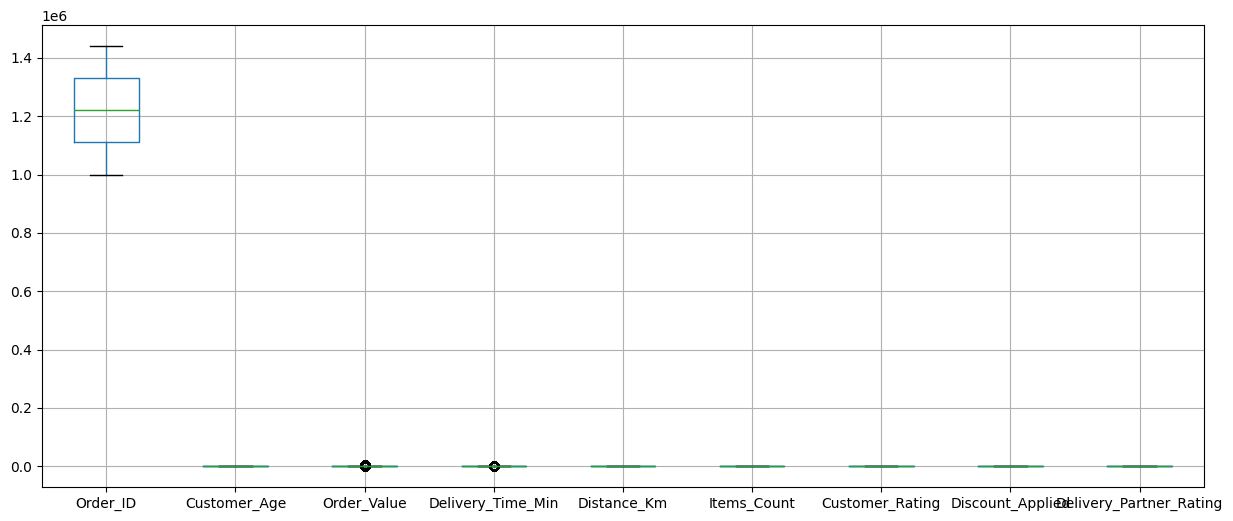

In [17]:
# box Plot
plt.figure(figsize=(15,6))
Qcommerce_data.boxplot()

<Axes: >

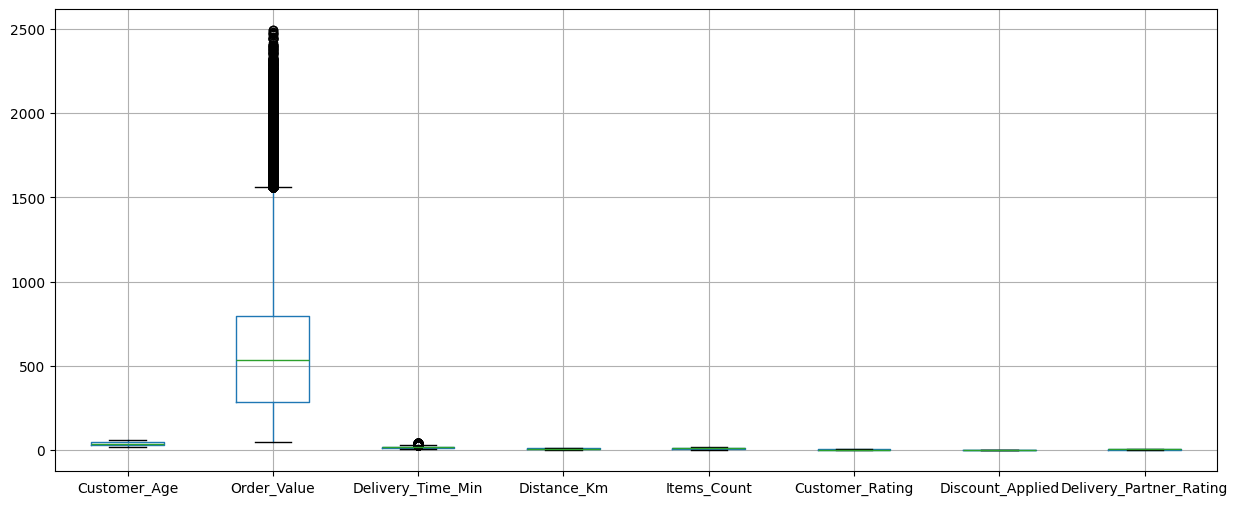

In [18]:
# Box plot withiout "Order_ID" column
plt.figure(figsize=(15,6))
Qcommerce_data.drop(columns=['Order_ID']).boxplot()

In [19]:
Qcommerce_data.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date
count,4.175110e+05,417511.000000,417511.000000,417511.000000,417511.000000,417511.000000,417511.000000,417511.000000,417511.000000,417511
mean,1.220230e+06,38.447904,570.533315,16.511987,7.757582,10.309486,3.041917,0.401264,3.799747,2024-02-15 15:16:27.857086720
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.000000,2023-01-01 00:00:00
25%,1.110087e+06,28.000000,287.000000,12.000000,4.100000,5.000000,2.000000,0.000000,3.000000,2023-07-26 00:00:00
50%,1.220180e+06,38.000000,532.000000,16.000000,7.800000,10.000000,3.000000,0.000000,4.000000,2024-02-16 00:00:00
75%,1.330388e+06,49.000000,796.000000,20.000000,11.400000,15.000000,4.000000,1.000000,4.000000,2024-09-08 00:00:00
max,1.440494e+06,59.000000,2492.000000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000,2025-03-31 00:00:00
std,1.271738e+05,12.124188,373.968277,6.348780,4.189533,5.631558,1.203077,0.490155,0.718031,NaN


In [20]:
# outlier identify
Q1 = Qcommerce_data['Order_Value'].quantile(0.25)
Q3 = Qcommerce_data['Order_Value'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit)
print(upper_limit)

-476.5
1559.5


In [21]:
Qcommerce= Qcommerce_data[
    (Qcommerce_data['Order_Value'] < lower_limit) |
    (Qcommerce_data['Order_Value'] > upper_limit)
]

Qcommerce

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date
13,1000014,Blinkit,Noida,48,1600,10,1.6,16,Beverages,Debit Card,3,1,4,2024-10-07
86,1000092,Swiggy Instamart,Chennai,45,1576,12,2.2,15,Snacks,Credit Card,4,1,4,2023-04-14
173,1000183,Flipkart Minutes,Gurgaon,46,1756,13,5.8,15,Personal Care,Debit Card,2,1,3,2023-01-02
323,1000338,Big Basket,Gurgaon,36,1578,20,12.9,7,Personal Care,Credit Card,4,1,3,2023-10-17
414,1000436,Swiggy Instamart,Bengluru,39,1597,17,9.4,16,Personal Care,Credit Card,2,1,4,2025-03-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417269,1440242,Zepto,Delhi,33,1589,5,9.1,13,Beverages,Credit Card,2,0,5,2025-03-27
417305,1440281,Swiggy Instamart,Chennai,20,1652,14,7.3,3,Snacks,Cash on Delivery,4,1,4,2023-02-07
417373,1440353,Swiggy Instamart,Noida,23,1597,21,14.6,14,Groceries,Cash on Delivery,3,1,4,2023-01-10
417443,1440424,Flipkart Minutes,Gurgaon,43,1707,11,0.8,9,Snacks,UPI,2,1,4,2023-01-09


In [22]:
Qcommerce

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date
13,1000014,Blinkit,Noida,48,1600,10,1.6,16,Beverages,Debit Card,3,1,4,2024-10-07
86,1000092,Swiggy Instamart,Chennai,45,1576,12,2.2,15,Snacks,Credit Card,4,1,4,2023-04-14
173,1000183,Flipkart Minutes,Gurgaon,46,1756,13,5.8,15,Personal Care,Debit Card,2,1,3,2023-01-02
323,1000338,Big Basket,Gurgaon,36,1578,20,12.9,7,Personal Care,Credit Card,4,1,3,2023-10-17
414,1000436,Swiggy Instamart,Bengluru,39,1597,17,9.4,16,Personal Care,Credit Card,2,1,4,2025-03-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417269,1440242,Zepto,Delhi,33,1589,5,9.1,13,Beverages,Credit Card,2,0,5,2025-03-27
417305,1440281,Swiggy Instamart,Chennai,20,1652,14,7.3,3,Snacks,Cash on Delivery,4,1,4,2023-02-07
417373,1440353,Swiggy Instamart,Noida,23,1597,21,14.6,14,Groceries,Cash on Delivery,3,1,4,2023-01-10
417443,1440424,Flipkart Minutes,Gurgaon,43,1707,11,0.8,9,Snacks,UPI,2,1,4,2023-01-09


In [23]:
Qcommerce.shape

(5776, 14)

In [24]:
Qcommerce.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5776 entries, 13 to 417508
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_ID                 5776 non-null   int64         
 1   Company                  5776 non-null   object        
 2   City                     5776 non-null   object        
 3   Customer_Age             5776 non-null   int64         
 4   Order_Value              5776 non-null   int64         
 5   Delivery_Time_Min        5776 non-null   int64         
 6   Distance_Km              5776 non-null   float64       
 7   Items_Count              5776 non-null   int64         
 8   Product_Category         5776 non-null   object        
 9   Payment_Method           5776 non-null   object        
 10  Customer_Rating          5776 non-null   int64         
 11  Discount_Applied         5776 non-null   int64         
 12  Delivery_Partner_Rating  5776 non-nu

#### Change Data_type 

In [25]:
# change data type of Order_ID
Qcommerce['Order_ID']=Qcommerce['Order_ID'].astype(str)

C:\Users\deepakkumar\AppData\Local\Temp\ipykernel_2988\4166224970.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Qcommerce['Order_ID']=Qcommerce['Order_ID'].astype(str)


<Axes: >

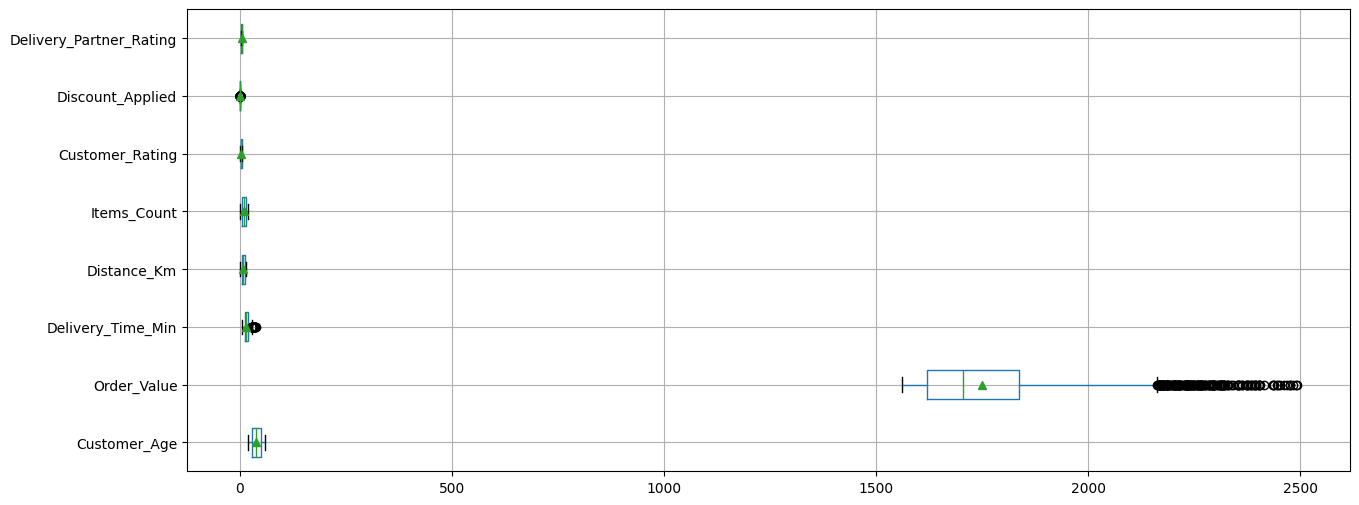

In [26]:
# Box plot withiout "Order_ID" column
plt.figure(figsize=(15,6))
Qcommerce.drop(columns=['Order_ID']).boxplot(vert= False , showmeans= True)

In [27]:
Qcommerce.describe()

,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date
count,5776.000000,5776.000000,5776.000000,5776.000000,5776.000000,5776.000000,5776.000000,5776.000000,5776
mean,38.477147,1750.926593,14.661184,7.824030,10.228186,3.202562,0.983553,3.789474,2024-02-12 08:51:01.495844864
min,18.000000,1560.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.000000,2023-01-01 00:00:00
25%,28.000000,1619.750000,11.000000,4.200000,5.000000,2.000000,1.000000,3.000000,2023-07-20 00:00:00
50%,38.000000,1705.000000,15.000000,7.800000,10.000000,3.000000,1.000000,4.000000,2024-02-15 00:00:00
75%,49.000000,1837.000000,18.000000,11.525000,15.000000,4.000000,1.000000,4.000000,2024-09-05 06:00:00
max,59.000000,2492.000000,39.000000,15.000000,19.000000,5.000000,1.000000,5.000000,2025-03-31 00:00:00
std,12.118570,168.863365,5.345904,4.226433,5.641026,1.182923,0.127199,0.724584,NaN


## Business Question

### 1) which quick commerce platform has the highest total revenue?

In [28]:
Qcommerce.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date
13,1000014,Blinkit,Noida,48,1600,10,1.6,16,Beverages,Debit Card,3,1,4,2024-10-07
86,1000092,Swiggy Instamart,Chennai,45,1576,12,2.2,15,Snacks,Credit Card,4,1,4,2023-04-14
173,1000183,Flipkart Minutes,Gurgaon,46,1756,13,5.8,15,Personal Care,Debit Card,2,1,3,2023-01-02
323,1000338,Big Basket,Gurgaon,36,1578,20,12.9,7,Personal Care,Credit Card,4,1,3,2023-10-17
414,1000436,Swiggy Instamart,Bengluru,39,1597,17,9.4,16,Personal Care,Credit Card,2,1,4,2025-03-22


In [29]:
# Group Data _ Calculate total order value for companies
Company_revenue=Qcommerce.groupby('Company')['Order_Value'].sum()
Company_revenue

Company
Amazon Now           911143
Big Basket          1214194
Blinkit             1911818
Dunzo                715045
Flipkart Minutes    1040318
Jio Mart             237333
Swiggy Instamart    2628472
Zepto               1455029
Name: Order_Value, dtype: int64

In [30]:
# sort Grouped Data
Company_revenue.sort_values()

Company
Jio Mart             237333
Dunzo                715045
Amazon Now           911143
Flipkart Minutes    1040318
Big Basket          1214194
Zepto               1455029
Blinkit             1911818
Swiggy Instamart    2628472
Name: Order_Value, dtype: int64

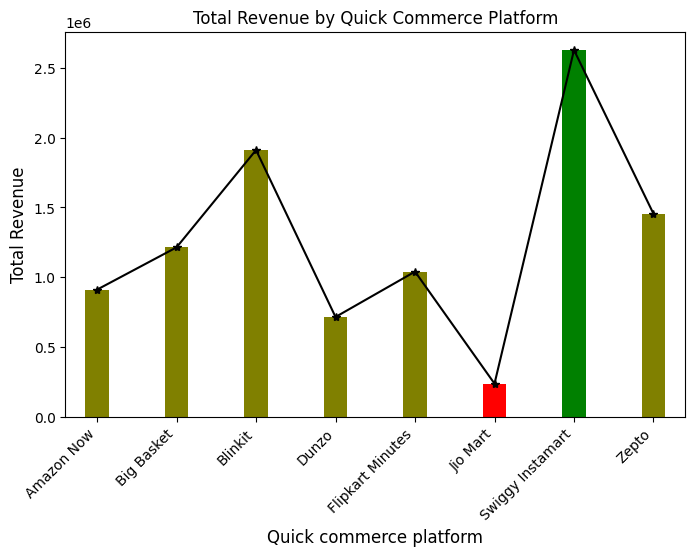

In [31]:
# Bar and Line chart
plt.figure(figsize=(8,5))
#find max and min revenue
max_val=Company_revenue.max()
min_val=Company_revenue.min()

# Assign colors based on value
colors=['green' if val == max_val else
       'red' if val == min_val else
        'olive'
        for val in Company_revenue]

#Draw Bar & Line chart at once
Company_revenue.plot(kind='bar',color=colors,width=0.3)
Company_revenue.plot(kind='line', color = 'black',marker='*')
plt.title("Total Revenue by Quick Commerce Platform")
plt.xlabel("Quick commerce platform", fontsize = 12)
plt.ylabel("Total Revenue", fontsize = 12)
plt.xticks(rotation=45, ha="right")
plt.show()



### 2) Which platform has the highest average order value(AOV)?

In [32]:
Qcommerce.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date
13,1000014,Blinkit,Noida,48,1600,10,1.6,16,Beverages,Debit Card,3,1,4,2024-10-07
86,1000092,Swiggy Instamart,Chennai,45,1576,12,2.2,15,Snacks,Credit Card,4,1,4,2023-04-14
173,1000183,Flipkart Minutes,Gurgaon,46,1756,13,5.8,15,Personal Care,Debit Card,2,1,3,2023-01-02
323,1000338,Big Basket,Gurgaon,36,1578,20,12.9,7,Personal Care,Credit Card,4,1,3,2023-10-17
414,1000436,Swiggy Instamart,Bengluru,39,1597,17,9.4,16,Personal Care,Credit Card,2,1,4,2025-03-22


In [33]:
# group data - calculate average order value for companies
AOV=Qcommerce.groupby('Company')['Order_Value'].mean().sort_values(ascending = False)

In [34]:
AOV

Company
Swiggy Instamart    1782.014915
Blinkit             1755.572084
Big Basket          1747.041727
Flipkart Minutes    1739.662207
Zepto               1738.385902
Amazon Now          1728.924099
Dunzo               1723.000000
Jio Mart            1695.235714
Name: Order_Value, dtype: float64

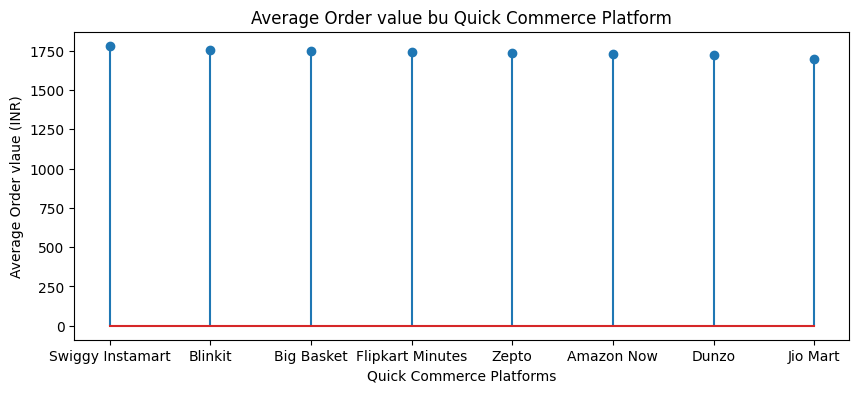

In [35]:
# stem chart
plt.figure(figsize=(10,4))
plt.stem(AOV.index, AOV.values)
plt.xlabel("Quick Commerce Platforms")
plt.ylabel("Average Order vlaue (INR)")
plt.title("Average Order value bu Quick Commerce Platform")
plt.show()


### 3) How does Customer Rating vary across platforms?

In [36]:
Qcommerce.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date
13,1000014,Blinkit,Noida,48,1600,10,1.6,16,Beverages,Debit Card,3,1,4,2024-10-07
86,1000092,Swiggy Instamart,Chennai,45,1576,12,2.2,15,Snacks,Credit Card,4,1,4,2023-04-14
173,1000183,Flipkart Minutes,Gurgaon,46,1756,13,5.8,15,Personal Care,Debit Card,2,1,3,2023-01-02
323,1000338,Big Basket,Gurgaon,36,1578,20,12.9,7,Personal Care,Credit Card,4,1,3,2023-10-17
414,1000436,Swiggy Instamart,Bengluru,39,1597,17,9.4,16,Personal Care,Credit Card,2,1,4,2025-03-22


In [37]:
# Group Data - Calculate average rating for companies
Qcommerce.groupby('Company')["Customer_Rating"].mean().sort_values(ascending=False)

Company
Blinkit             3.589532
Swiggy Instamart    3.294237
Zepto               3.274791
Big Basket          3.083453
Flipkart Minutes    3.051839
Amazon Now          2.990512
Jio Mart            2.885714
Dunzo               2.508434
Name: Customer_Rating, dtype: float64

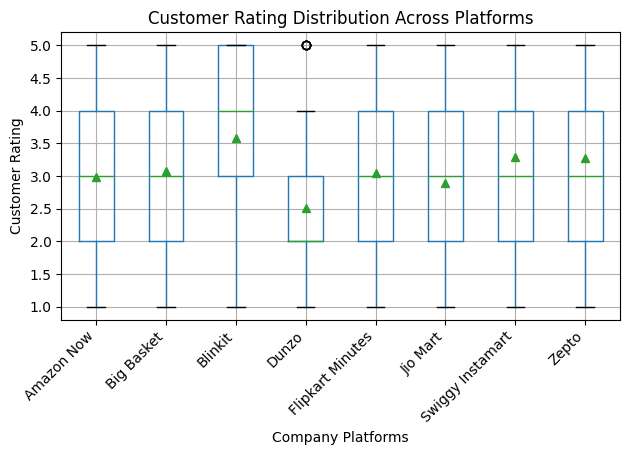

In [38]:
# Box plot
Qcommerce.boxplot(column = 'Customer_Rating', by= 'Company',showmeans=True)
plt.suptitle("")
plt.title("Customer Rating Distribution Across Platforms")
plt.xlabel("Company Platforms")
plt.ylabel("Customer Rating")
plt.xticks(rotation = 45 , ha = 'right')
plt.tight_layout() #auto adjust spacing
plt.show()

In [39]:
# group Data
Grouped_Rating=Qcommerce.groupby(['Company','Customer_Rating']).size().unstack(fill_value=0)
Grouped_Rating

Customer_Rating,1,2,3,4,5
Company,,,,,
Amazon Now,59,138,133,143,54
Big Basket,62,163,200,195,75
Blinkit,8,227,254,315,285
Dunzo,90,132,90,98,5
Flipkart Minutes,47,171,153,158,69
Jio Mart,19,34,41,36,10
Swiggy Instamart,72,357,395,367,284
Zepto,53,193,209,235,147


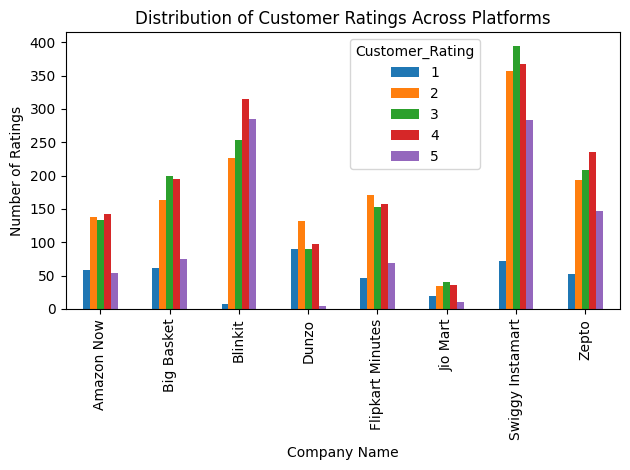

In [40]:
# Bar chart for Grouped Ratings
Grouped_Rating.plot(kind = 'bar')
plt.xlabel("Company Name")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Customer Ratings Across Platforms")
plt.legend(title= 'Customer_Rating',bbox_to_anchor=(0.5,1), loc = 'upper left')

plt.tight_layout()
plt.show()




In [41]:
#sns.pairplot(data=Qcommerce)
#plt.show()

### 4) Does 'Delivery Time' affects the Delivery partner Ratings?

In [42]:
Qcommerce.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date
13,1000014,Blinkit,Noida,48,1600,10,1.6,16,Beverages,Debit Card,3,1,4,2024-10-07
86,1000092,Swiggy Instamart,Chennai,45,1576,12,2.2,15,Snacks,Credit Card,4,1,4,2023-04-14
173,1000183,Flipkart Minutes,Gurgaon,46,1756,13,5.8,15,Personal Care,Debit Card,2,1,3,2023-01-02
323,1000338,Big Basket,Gurgaon,36,1578,20,12.9,7,Personal Care,Credit Card,4,1,3,2023-10-17
414,1000436,Swiggy Instamart,Bengluru,39,1597,17,9.4,16,Personal Care,Credit Card,2,1,4,2025-03-22


In [43]:
Qcommerce["Delivery_Time_Min"].mean()

np.float64(14.661184210526315)

In [44]:
Qcommerce["Delivery_Partner_Rating"].mean()

np.float64(3.789473684210526)

In [45]:
# Calculate average rating for delivery timings
x=Qcommerce.groupby("Delivery_Time_Min")["Delivery_Partner_Rating"].mean()
x

Delivery_Time_Min
5     3.738717
6     3.788321
7     3.788136
8     3.751724
9     3.779141
10    3.738589
11    3.831804
12    3.779614
13    3.746867
14    3.841709
15    3.727064
16    3.848214
17    3.808036
18    3.811563
19    3.797619
20    3.834746
21    3.756637
22    3.846774
23    3.750000
24    3.827586
25    3.829268
26    3.805556
27    3.733333
28    3.714286
29    3.526316
30    3.777778
31    4.125000
32    4.222222
33    3.200000
34    3.500000
35    3.000000
36    4.500000
39    4.000000
Name: Delivery_Partner_Rating, dtype: float64

In [46]:
Qcommerce["Delivery_Time_Min"].corr(Qcommerce["Delivery_Partner_Rating"])

np.float64(0.017970671188391872)

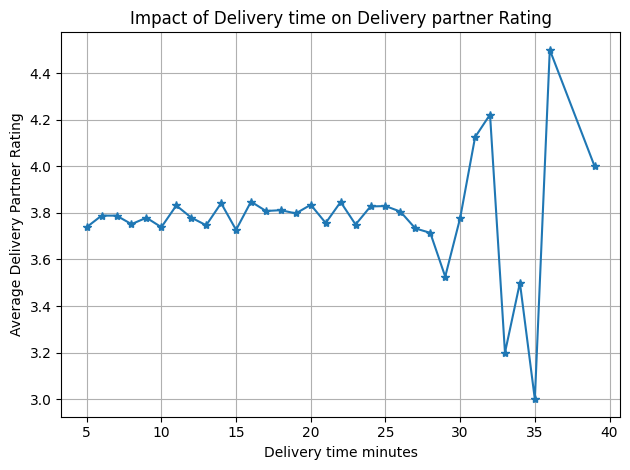

In [47]:
# line chart
x.plot(marker = '*')
plt.xlabel("Delivery time minutes")
plt.ylabel("Average Delivery Partner Rating")
plt.title("Impact of Delivery time on Delivery partner Rating")
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
# syntax : pd.cut(col_name,bins,labels)
Qcommerce["Delivery_rating"] =pd.cut(Qcommerce['Delivery_Time_Min'],bins= (0,10,20,30,40), 
       labels= ("Very Fast Delivery","Fast Delivery","Normal Delivery","Slow Delivery"))

C:\Users\deepakkumar\AppData\Local\Temp\ipykernel_2988\519866935.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Qcommerce["Delivery_rating"] =pd.cut(Qcommerce['Delivery_Time_Min'],bins= (0,10,20,30,40),


In [49]:
Qcommerce

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date,Delivery_rating
13,1000014,Blinkit,Noida,48,1600,10,1.6,16,Beverages,Debit Card,3,1,4,2024-10-07,Very Fast Delivery
86,1000092,Swiggy Instamart,Chennai,45,1576,12,2.2,15,Snacks,Credit Card,4,1,4,2023-04-14,Fast Delivery
173,1000183,Flipkart Minutes,Gurgaon,46,1756,13,5.8,15,Personal Care,Debit Card,2,1,3,2023-01-02,Fast Delivery
323,1000338,Big Basket,Gurgaon,36,1578,20,12.9,7,Personal Care,Credit Card,4,1,3,2023-10-17,Fast Delivery
414,1000436,Swiggy Instamart,Bengluru,39,1597,17,9.4,16,Personal Care,Credit Card,2,1,4,2025-03-22,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417269,1440242,Zepto,Delhi,33,1589,5,9.1,13,Beverages,Credit Card,2,0,5,2025-03-27,Very Fast Delivery
417305,1440281,Swiggy Instamart,Chennai,20,1652,14,7.3,3,Snacks,Cash on Delivery,4,1,4,2023-02-07,Fast Delivery
417373,1440353,Swiggy Instamart,Noida,23,1597,21,14.6,14,Groceries,Cash on Delivery,3,1,4,2023-01-10,Normal Delivery
417443,1440424,Flipkart Minutes,Gurgaon,43,1707,11,0.8,9,Snacks,UPI,2,1,4,2023-01-09,Fast Delivery


In [50]:
Avg_rating=Qcommerce.groupby("Delivery_rating")["Delivery_Partner_Rating"].mean()
Avg_rating

C:\Users\deepakkumar\AppData\Local\Temp\ipykernel_2988\342176133.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Avg_rating=Qcommerce.groupby("Delivery_rating")["Delivery_Partner_Rating"].mean()


Delivery_rating
Very Fast Delivery    3.755918
Fast Delivery         3.801192
Normal Delivery       3.777444
Slow Delivery         3.928571
Name: Delivery_Partner_Rating, dtype: float64

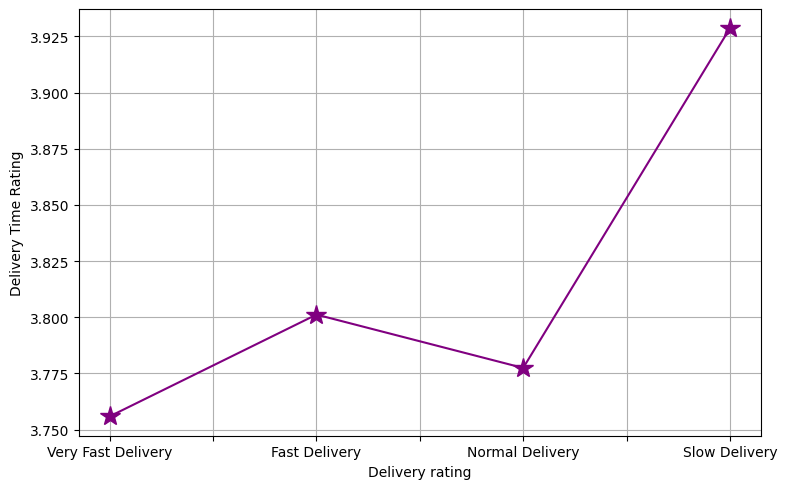

In [51]:
plt.figure(figsize=(8,5))
Avg_rating.plot(marker = '*',markersize=15,color='purple')
plt.xlabel("Delivery rating")
plt.ylabel("Delivery Time Rating")
plt.grid(True)
plt.tight_layout()
plt.show()

### 5) What is the most popuplar product category on swiggy Instamart,for the people of age between 30-40 in Mumbai?

In [52]:
Qcommerce.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date,Delivery_rating
13,1000014,Blinkit,Noida,48,1600,10,1.6,16,Beverages,Debit Card,3,1,4,2024-10-07,Very Fast Delivery
86,1000092,Swiggy Instamart,Chennai,45,1576,12,2.2,15,Snacks,Credit Card,4,1,4,2023-04-14,Fast Delivery
173,1000183,Flipkart Minutes,Gurgaon,46,1756,13,5.8,15,Personal Care,Debit Card,2,1,3,2023-01-02,Fast Delivery
323,1000338,Big Basket,Gurgaon,36,1578,20,12.9,7,Personal Care,Credit Card,4,1,3,2023-10-17,Fast Delivery
414,1000436,Swiggy Instamart,Bengluru,39,1597,17,9.4,16,Personal Care,Credit Card,2,1,4,2025-03-22,Fast Delivery


In [53]:
#filtering
Qcommerce_pc=Qcommerce[
    (Qcommerce['Company']== 'Swiggy Instamart') & 
    ((Qcommerce['Customer_Age'] >=30) & (Qcommerce['Customer_Age'] <=40 ))&
    (Qcommerce['City']== 'Mumbai')
]
Qcommerce_pc

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date,Delivery_rating
47459,1050041,Swiggy Instamart,Mumbai,35,2354,14,5.4,5,Snacks,Credit Card,4,1,3,2023-11-25,Fast Delivery
62872,1066365,Swiggy Instamart,Mumbai,40,1653,16,7.6,16,Fruits & Vegetables,UPI,5,1,4,2023-07-28,Fast Delivery
63010,1066510,Swiggy Instamart,Mumbai,31,1658,14,0.5,9,Household,Cash on Delivery,4,1,3,2024-06-11,Fast Delivery
96744,1102026,Swiggy Instamart,Mumbai,38,1586,11,0.8,8,Groceries,Cash on Delivery,5,1,3,2023-12-12,Fast Delivery
104520,1110241,Swiggy Instamart,Mumbai,30,1662,13,4.0,5,Household,Cash on Delivery,2,1,3,2023-03-18,Fast Delivery
109201,1115195,Swiggy Instamart,Mumbai,40,1837,16,6.2,1,Personal Care,Wallet,4,1,4,2024-01-30,Fast Delivery
114437,1120703,Swiggy Instamart,Mumbai,37,1653,20,11.1,9,Snacks,Wallet,2,1,5,2024-09-18,Fast Delivery
166203,1175285,Swiggy Instamart,Mumbai,33,1912,20,10.2,14,Beverages,Cash on Delivery,4,1,4,2024-02-10,Fast Delivery
166206,1175288,Swiggy Instamart,Mumbai,37,1896,21,13.6,13,Fruits & Vegetables,Credit Card,2,1,4,2023-01-21,Normal Delivery
166808,1175916,Swiggy Instamart,Mumbai,33,1851,19,8.4,15,Fruits & Vegetables,Cash on Delivery,2,1,3,2024-03-05,Fast Delivery


In [54]:
# Most Popular product Category 
Qcommerce_pc['Product_Category'].value_counts()

Product_Category
Groceries              6
Beverages              6
Snacks                 4
Personal Care          4
Fruits & Vegetables    4
Household              2
Dairy                  2
Name: count, dtype: int64

### 6) Which cities should these company expand into based on performance

In [55]:
Qcommerce

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date,Delivery_rating
13,1000014,Blinkit,Noida,48,1600,10,1.6,16,Beverages,Debit Card,3,1,4,2024-10-07,Very Fast Delivery
86,1000092,Swiggy Instamart,Chennai,45,1576,12,2.2,15,Snacks,Credit Card,4,1,4,2023-04-14,Fast Delivery
173,1000183,Flipkart Minutes,Gurgaon,46,1756,13,5.8,15,Personal Care,Debit Card,2,1,3,2023-01-02,Fast Delivery
323,1000338,Big Basket,Gurgaon,36,1578,20,12.9,7,Personal Care,Credit Card,4,1,3,2023-10-17,Fast Delivery
414,1000436,Swiggy Instamart,Bengluru,39,1597,17,9.4,16,Personal Care,Credit Card,2,1,4,2025-03-22,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417269,1440242,Zepto,Delhi,33,1589,5,9.1,13,Beverages,Credit Card,2,0,5,2025-03-27,Very Fast Delivery
417305,1440281,Swiggy Instamart,Chennai,20,1652,14,7.3,3,Snacks,Cash on Delivery,4,1,4,2023-02-07,Fast Delivery
417373,1440353,Swiggy Instamart,Noida,23,1597,21,14.6,14,Groceries,Cash on Delivery,3,1,4,2023-01-10,Normal Delivery
417443,1440424,Flipkart Minutes,Gurgaon,43,1707,11,0.8,9,Snacks,UPI,2,1,4,2023-01-09,Fast Delivery


In [56]:
# Group Data and Apply Aggregate functions

city_performance=Qcommerce.groupby(['Company', 'City']).agg(
    Total_orders=('Order_ID','count'),
    Avg_ratings=('Customer_Rating','mean'),
    Avg_Delivery_Time=('Delivery_Time_Min', 'mean'),
    Total_Revenue=('Order_Value','sum')
).reset_index()
city_performance

,Company,City,Total_orders,Avg_ratings,Avg_Delivery_Time,Total_Revenue
0,Amazon Now,Amritsar,35,3.000000,18.028571,61400
1,Amazon Now,Bengluru,59,3.372881,19.389831,100912
2,Amazon Now,Chennai,31,2.967742,18.580645,53218
3,Amazon Now,Delhi,59,2.983051,8.152542,101630
4,Amazon Now,Gurgaon,77,3.025974,18.129870,134663
...,...,...,...,...,...,...
91,Zepto,Jaipur,29,3.482759,12.103448,49334
92,Zepto,Kolkata,66,2.984848,8.560606,113597
93,Zepto,Mumbai,82,3.463415,9.926829,141335
94,Zepto,Noida,120,3.275000,8.625000,207624


In [57]:
# filtering Best cities based on given condition
best_cities=city_performance[
    (city_performance['Avg_ratings'] >=3.5) &
    (city_performance['Avg_Delivery_Time'] <=15) &
    (city_performance['Total_orders']> city_performance['Total_orders'].median())
    ]
best_cities

,Company,City,Total_orders,Avg_ratings,Avg_Delivery_Time,Total_Revenue
24,Blinkit,Amritsar,91,3.714286,14.109890,159025
27,Blinkit,Delhi,95,3.726316,5.768421,165360
28,Blinkit,Gurgaon,165,3.587879,14.090909,295344
32,Blinkit,Kolkata,73,3.739726,13.876712,126008
34,Blinkit,Noida,174,3.580460,14.057471,306987
75,Swiggy Instamart,Delhi,137,3.510949,6.408759,242949
85,Zepto,Bengluru,72,4.041667,8.791667,126185


In [58]:
best_cities[['Company','City']]

,Company,City
24,Blinkit,Amritsar
27,Blinkit,Delhi
28,Blinkit,Gurgaon
32,Blinkit,Kolkata
34,Blinkit,Noida
75,Swiggy Instamart,Delhi
85,Zepto,Bengluru


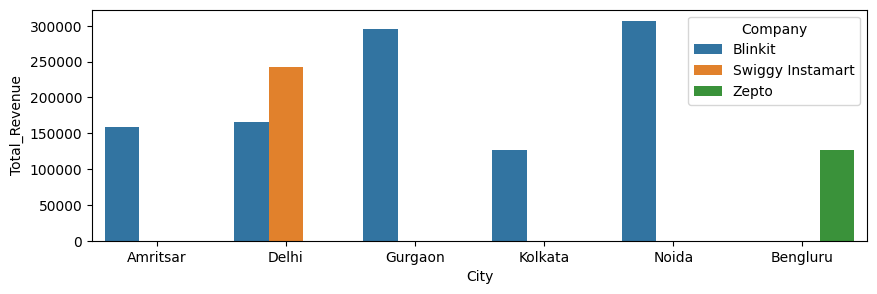

In [59]:
plt.figure(figsize=(10,3))
sns.barplot(data= best_cities,x='City',y='Total_Revenue', hue='Company')
plt.legend(title='Company',bbox_to_anchor=(1,1),loc='upper right')
plt.show()

###  7) Are discounts increasing order volume or just reducing revenue?

In [60]:
Qcommerce

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,order_date,Delivery_rating
13,1000014,Blinkit,Noida,48,1600,10,1.6,16,Beverages,Debit Card,3,1,4,2024-10-07,Very Fast Delivery
86,1000092,Swiggy Instamart,Chennai,45,1576,12,2.2,15,Snacks,Credit Card,4,1,4,2023-04-14,Fast Delivery
173,1000183,Flipkart Minutes,Gurgaon,46,1756,13,5.8,15,Personal Care,Debit Card,2,1,3,2023-01-02,Fast Delivery
323,1000338,Big Basket,Gurgaon,36,1578,20,12.9,7,Personal Care,Credit Card,4,1,3,2023-10-17,Fast Delivery
414,1000436,Swiggy Instamart,Bengluru,39,1597,17,9.4,16,Personal Care,Credit Card,2,1,4,2025-03-22,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417269,1440242,Zepto,Delhi,33,1589,5,9.1,13,Beverages,Credit Card,2,0,5,2025-03-27,Very Fast Delivery
417305,1440281,Swiggy Instamart,Chennai,20,1652,14,7.3,3,Snacks,Cash on Delivery,4,1,4,2023-02-07,Fast Delivery
417373,1440353,Swiggy Instamart,Noida,23,1597,21,14.6,14,Groceries,Cash on Delivery,3,1,4,2023-01-10,Normal Delivery
417443,1440424,Flipkart Minutes,Gurgaon,43,1707,11,0.8,9,Snacks,UPI,2,1,4,2023-01-09,Fast Delivery


In [61]:
# Count the number of orders with and without discount
Qcommerce['Discount_Applied'].value_counts()

Discount_Applied
1    5681
0      95
Name: count, dtype: int64

In [62]:
# group Data - Calculate average order value
Dis_order_value=Qcommerce.groupby('Discount_Applied')['Order_Value'].mean()
Dis_order_value

Discount_Applied
0    1699.284211
1    1751.790178
Name: Order_Value, dtype: float64

In [63]:
# group data - Calculate sum of items count
Dis_items_count=Qcommerce.groupby('Discount_Applied')['Items_Count'].sum()
Dis_items_count

Discount_Applied
0      931
1    58147
Name: Items_Count, dtype: int64

In [64]:
x=Qcommerce['Discount_Applied'].unique()
x

array([1, 0])

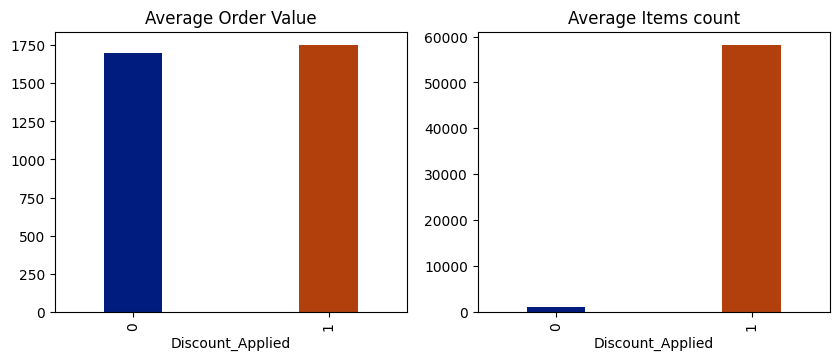

In [65]:
plt.figure(figsize=(10,8))
colors=sns.color_palette('dark',len(x))

plt.subplot(2,2,1)
Dis_order_value.plot(kind='bar',width=0.3,color=colors)
plt.title("Average Order Value")

plt.subplot(2,2,2)
Dis_items_count.plot(kind='bar',width=0.3,color=colors)
plt.title("Average Items count")


plt.show()

### 8) which company has the best operational efficiency (Delivery Time vs Order Volume)?

In [66]:
#Group Data and apply aggregate function
Company_effic=Qcommerce.groupby('Company').agg(
    Total_orders=('Order_ID','count'),
    Avg_Delivery_Time=('Delivery_Time_Min','mean')
).reset_index()
Company_effic    

,Company,Total_orders,Avg_Delivery_Time
0,Amazon Now,527,17.815939
1,Big Basket,695,17.002878
2,Blinkit,1089,14.198347
3,Dunzo,415,12.963855
4,Flipkart Minutes,598,16.272575
5,Jio Mart,140,21.978571
6,Swiggy Instamart,1475,15.287458
7,Zepto,837,8.695341


In [67]:
# Normalize values for fair comparision

from sklearn.preprocessing import MinMaxScaler

# Scaling both Columns to the same range (0 to1) so that they can be fairly compared and combined
scaler=MinMaxScaler()   # create a scaling object

Company_effic[['Total_Orders_Scaled','Avg_Delivery_Time_Scaled']] = scaler.fit_transform(Company_effic[['Total_orders','Avg_Delivery_Time']]
)

In [68]:
Company_effic

,Company,Total_orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled
0,Amazon Now,527,17.815939,0.289888,0.686625
1,Big Basket,695,17.002878,0.415730,0.625415
2,Blinkit,1089,14.198347,0.710861,0.414282
3,Dunzo,415,12.963855,0.205993,0.321346
4,Flipkart Minutes,598,16.272575,0.343071,0.570436
5,Jio Mart,140,21.978571,0.000000,1.000000
6,Swiggy Instamart,1475,15.287458,1.000000,0.496274
7,Zepto,837,8.695341,0.522097,0.000000


In [69]:
# Efficiency Score (higher orders,lower time)
Company_effic['Efficiency_Score']=Company_effic['Total_Orders_Scaled']-Company_effic['Avg_Delivery_Time_Scaled']
Company_effic

,Company,Total_orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
0,Amazon Now,527,17.815939,0.289888,0.686625,-0.396737
1,Big Basket,695,17.002878,0.415730,0.625415,-0.209685
2,Blinkit,1089,14.198347,0.710861,0.414282,0.296579
3,Dunzo,415,12.963855,0.205993,0.321346,-0.115354
4,Flipkart Minutes,598,16.272575,0.343071,0.570436,-0.227365
5,Jio Mart,140,21.978571,0.000000,1.000000,-1.000000
6,Swiggy Instamart,1475,15.287458,1.000000,0.496274,0.503726
7,Zepto,837,8.695341,0.522097,0.000000,0.522097


In [70]:
#Sort by best efficiency

eff=Company_effic.sort_values(by='Efficiency_Score',ascending=False)
eff

,Company,Total_orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
7,Zepto,837,8.695341,0.522097,0.000000,0.522097
6,Swiggy Instamart,1475,15.287458,1.000000,0.496274,0.503726
2,Blinkit,1089,14.198347,0.710861,0.414282,0.296579
3,Dunzo,415,12.963855,0.205993,0.321346,-0.115354
1,Big Basket,695,17.002878,0.415730,0.625415,-0.209685
4,Flipkart Minutes,598,16.272575,0.343071,0.570436,-0.227365
0,Amazon Now,527,17.815939,0.289888,0.686625,-0.396737
5,Jio Mart,140,21.978571,0.000000,1.000000,-1.000000


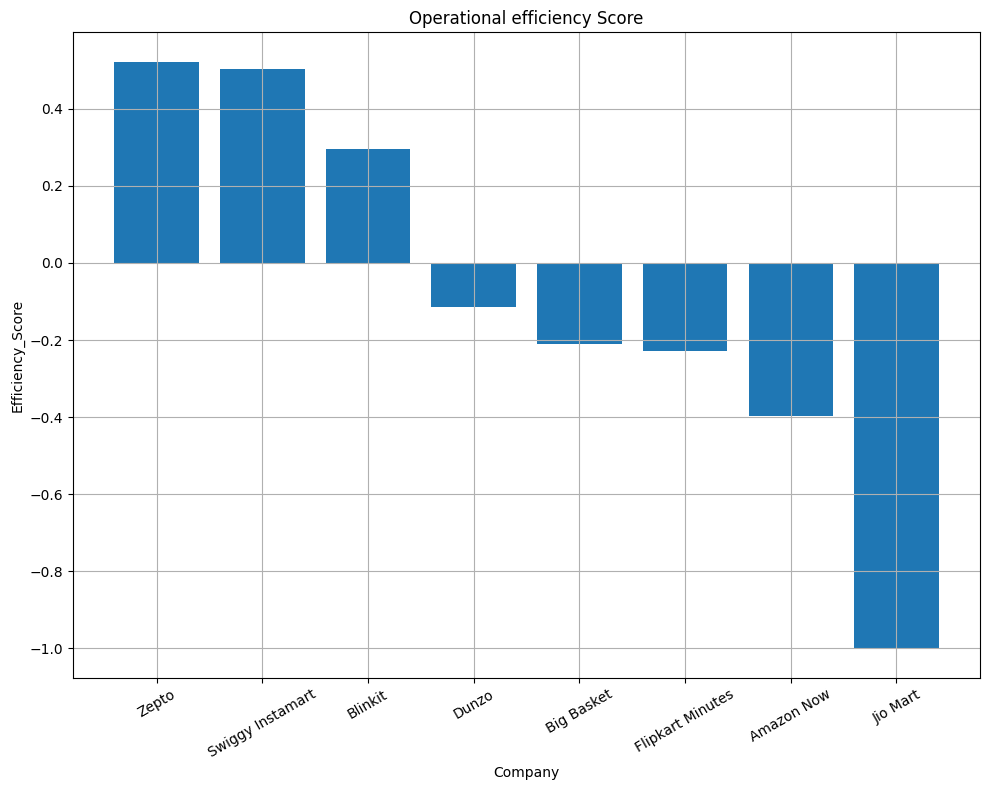

In [71]:
#plot
plt.figure(figsize=(10,8))
plt.xlabel('Company')
plt.ylabel('Efficiency_Score')
plt.title('Operational efficiency Score')
plt.bar(eff['Company'],eff['Efficiency_Score'])
plt.xticks(rotation=30)

plt.grid(True)

plt.tight_layout()
plt.show()

## Mini Dashboard

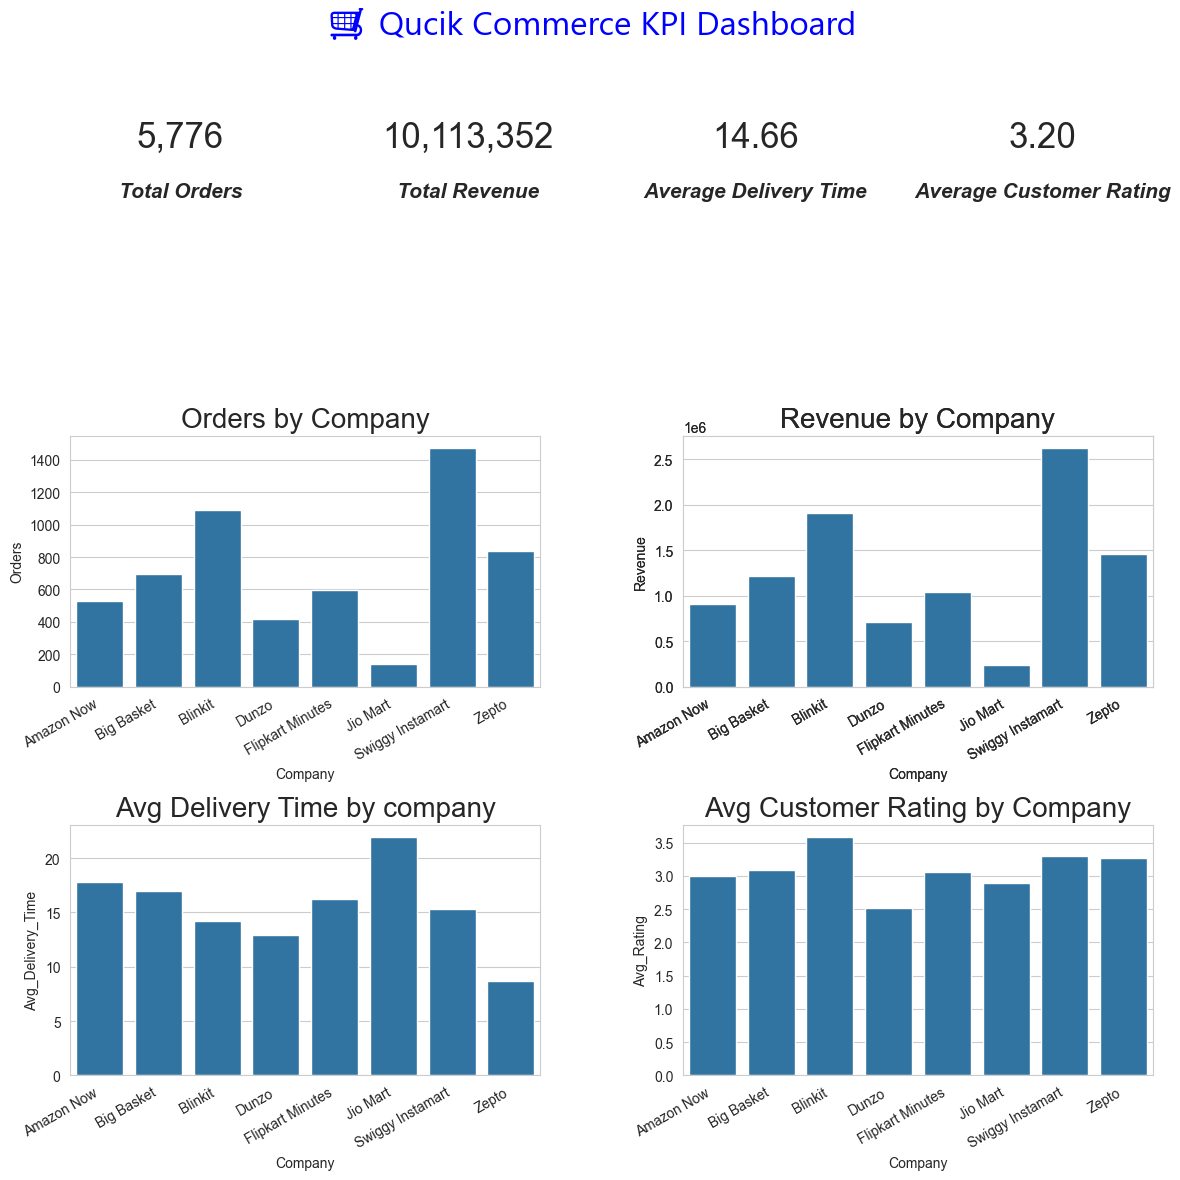

In [94]:
# create Dashboard layout


fig=plt.figure(figsize=(12,12))
sns.set_style("whitegrid")

#kpi calculations

Total_orders=Qcommerce['Order_ID'].count()
Total_revenue=Qcommerce['Order_Value'].sum()
avg_delivery_time=Qcommerce['Delivery_Time_Min'].mean()
avg_rating =Qcommerce['Customer_Rating'].mean()

#kpi cards

plt.subplot2grid((3,4),(0,0))
plt.axis('off')
plt.text(0.5,0.6,f"{Total_orders:,}",fontsize=25,ha='center')
plt.text(0.5,0.4,"Total Orders", fontsize=15,ha='center',fontstyle='italic',fontweight='bold')


plt.subplot2grid((3,4),(0,1))
plt.axis('off')
plt.text(0.5,0.6,f"{Total_revenue:,}",fontsize=25,ha='center')
plt.text(0.5,0.4,"Total Revenue", fontsize=15,ha='center',fontstyle='italic',fontweight='bold')



plt.subplot2grid((3,4),(0,2))
plt.axis('off')
plt.text(0.5,0.6,f"{avg_delivery_time:.2f}",fontsize=25,ha='center')
plt.text(0.5,0.4,"Average Delivery Time", fontsize=15,ha='center',fontstyle='italic',fontweight='bold')

plt.subplot2grid((3,4),(0,3))
plt.axis('off')
plt.text(0.5,0.6,f"{avg_rating:.2f}",fontsize=25,ha='center')
plt.text(0.5,0.4,"Average Customer Rating", fontsize=15,ha='center',fontstyle='italic',fontweight='bold')

#Company Level Metrics
Company_metrics = Qcommerce.groupby('Company').agg(Orders = ('Order_ID','count'),
                                                   Revenue = ('Order_Value','sum'),
                                                   Avg_Delivery_Time =("Delivery_Time_Min",'mean'),
                                                   Avg_Rating= ("Customer_Rating", 'mean')).reset_index()
#charts section
# Orders by Company
plt.subplot2grid((3,2),(1,0))
sns.barplot(data = Company_metrics , x = 'Company',y='Orders')
plt.title("Orders by Company", fontsize = 20)
plt.xticks(rotation=30, ha ='right')

# Revenue by company
plt.subplot2grid((3,2),(1,1))
sns.barplot(data = Company_metrics , x = 'Company',y='Revenue')
plt.title("Revenue by Company", fontsize = 20)
plt.xticks(rotation=30, ha ='right')

# Revenue by company
plt.subplot2grid((3,2),(1,1))
sns.barplot(data = Company_metrics , x = 'Company',y='Revenue')
plt.title("Revenue by Company", fontsize = 20)
plt.xticks(rotation=30, ha ='right')

# Avg delivery time by company
plt.subplot2grid((3,2),(2,0))
sns.barplot(data = Company_metrics , x = 'Company',y='Avg_Delivery_Time')
plt.title("Avg Delivery Time by company", fontsize = 20)
plt.xticks(rotation=30, ha ='right')

# Avg rating by company
plt.subplot2grid((3,2),(2,1))
sns.barplot(data = Company_metrics , x = 'Company',y='Avg_Rating')
plt.title("Avg Customer Rating by Company", fontsize = 20)
plt.xticks(rotation=30, ha ='right')

# Dashboard title
plt.rcParams['font.family']="Segoe UI Emoji"
plt.suptitle("🛒 Qucik Commerce KPI Dashboard ",fontsize =24,color="blue")

plt.tight_layout()
plt.show()

In [89]:
Company_metrics

,Company,Orders,Revenue,Avg_Delivery_Time,Avg_Rating
0,Amazon Now,527,911143,17.815939,2.990512
1,Big Basket,695,1214194,17.002878,3.083453
2,Blinkit,1089,1911818,14.198347,3.589532
3,Dunzo,415,715045,12.963855,2.508434
4,Flipkart Minutes,598,1040318,16.272575,3.051839
5,Jio Mart,140,237333,21.978571,2.885714
6,Swiggy Instamart,1475,2628472,15.287458,3.294237
7,Zepto,837,1455029,8.695341,3.274791
